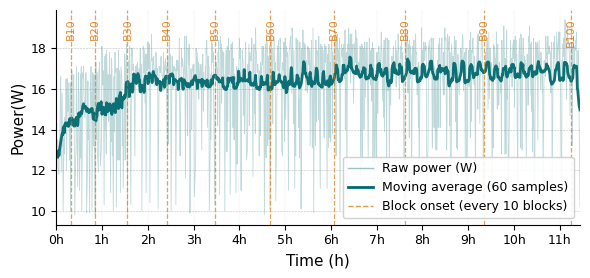

PDF : /home/paco/Proyectos/WAID/plots/power_timeseries.pdf
PNG : /home/paco/Proyectos/WAID/plots/power_timeseries.png
Run ID    : waidplus_11n4_L3
Muestras  : 6225
Bloques   : 100
Duración  : 11.44 h
μ         : 16.36 W
σ         : 2.10 W
Rango     : [9.7, 19.5] W


In [6]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Rutas ──────────────────────────────────────────────────────────────────
DEVICE = "Jetson"

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

ROOT_DIR   = BASE_DIR.parent
DEVICE_DIR = ROOT_DIR / "logs" / DEVICE
PLOTS_DIR  = ROOT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

POWER_CSV  = DEVICE_DIR / "history_ReTrain.csv"
BLOCKS_CSV = DEVICE_DIR / "waidplus_blocks_times.csv"
OUTPUT_PDF = PLOTS_DIR  / "power_timeseries.pdf"
OUTPUT_PNG = PLOTS_DIR  / "power_timeseries.png"

# ── Configuración ──────────────────────────────────────────────────────────
BLOCKS_TZ           = "Europe/Madrid"
ROLL_WINDOW         = 60
DOWNSAMPLE          = 5
BLOCK_MARKERS_EVERY = 10

COLOR_RAW    = "#01696f"
COLOR_SMOOTH = "#01696f"
COLOR_MARKER = "#da7101"

# ── Carga de datos ─────────────────────────────────────────────────────────
df_power = pd.read_csv(POWER_CSV)
df_power["timestamp"] = pd.to_datetime(df_power["last_changed"], utc=True)
df_power["power_W"]   = pd.to_numeric(df_power["state"], errors="coerce")
df_power = (df_power
            .dropna(subset=["power_W"])
            .sort_values("timestamp")
            .reset_index(drop=True))

df_blocks = pd.read_csv(BLOCKS_CSV)
run_id = df_blocks.iloc[0]["RunId"]

# ── Parseo de bloques ──────────────────────────────────────────────────────
blocks = []
n_blocks = (len(df_blocks.columns) - 1) // 2
for i in range(1, n_blocks + 1):
    ini_col, fin_col = f"B{i}_Ini", f"B{i}_Fin"
    if ini_col not in df_blocks.columns:
        break
    t_ini = (pd.to_datetime(df_blocks.iloc[0][ini_col])
               .tz_localize(BLOCKS_TZ).tz_convert("UTC"))
    t_fin = (pd.to_datetime(df_blocks.iloc[0][fin_col])
               .tz_localize(BLOCKS_TZ).tz_convert("UTC"))
    blocks.append({"block": i, "t_ini": t_ini, "t_fin": t_fin})

blocks_df = pd.DataFrame(blocks)

# ── Tiempo relativo en horas desde el primer bloque ────────────────────────
t0 = blocks_df["t_ini"].iloc[0]

df_power["t_h"] = (df_power["timestamp"] - t0).dt.total_seconds() / 3600.0
blocks_df["t_h_ini"] = (blocks_df["t_ini"] - t0).dt.total_seconds() / 3600.0
blocks_df["t_h_fin"] = (blocks_df["t_fin"] - t0).dt.total_seconds() / 3600.0

# ── Media móvil ────────────────────────────────────────────────────────────
df_power["power_smooth"] = (df_power["power_W"]
                             .rolling(window=ROLL_WINDOW, center=True, min_periods=1)
                             .mean())

# ── Downsample + recorte desde hora 0 ─────────────────────────────────────
df_plot = df_power.iloc[::DOWNSAMPLE].copy()
df_plot = df_plot[df_plot["t_h"] >= 0].copy()
t_max   = df_plot["t_h"].max()

# ── Figura ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Señal raw
ax.plot(df_plot["t_h"], df_plot["power_W"],
        color=COLOR_RAW, linewidth=0.6, alpha=0.25, label="Potencia raw (W)")

# Media móvil
ax.plot(df_plot["t_h"], df_plot["power_smooth"],
        color=COLOR_SMOOTH, linewidth=2.0, alpha=0.95,
        label=f"Media móvil ({ROLL_WINDOW} muestras)")

# ── Eje X: empieza en 0, tick cada hora ───────────────────────────────────
ax.set_xlim(left=0, right=t_max)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}h" if x == int(x) else f"{x:.1f}h"))

# Líneas verticales en inicio de bloques clave
key_blocks = blocks_df[blocks_df["block"] % BLOCK_MARKERS_EVERY == 0]
for _, row in key_blocks.iterrows():
    ax.axvline(x=row["t_h_ini"], color=COLOR_MARKER, linewidth=0.9,
               linestyle="--", alpha=0.65)
    ax.text(row["t_h_ini"], ax.get_ylim()[1] * 0.98,
            f'B{int(row["block"])}',
            fontsize=8, color=COLOR_MARKER, ha="center", va="top",
            rotation=90, alpha=0.8)

# Etiquetas y título
ax.set_xlabel("Time (h)", fontsize=11)
ax.set_ylabel("Power(W)", fontsize=11)
#ax.set_title(f"Potencia instantánea — {run_id}", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5, color="gray")
ax.grid(axis="x", linestyle=":",  linewidth=0.3, alpha=0.4, color="gray")

# Leyenda
legend_handles = [
    plt.Line2D([0], [0], color=COLOR_RAW,    lw=1,  alpha=0.4,label="Raw power (W)"),
    plt.Line2D([0], [0], color=COLOR_SMOOTH, lw=2.0,label=f"Moving average ({ROLL_WINDOW} samples)"),
    plt.Line2D([0], [0], color=COLOR_MARKER, lw=1, linestyle="--", alpha=0.7,label=f"Block onset (every {BLOCK_MARKERS_EVERY} blocks)"),
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right",framealpha=0.9, edgecolor="#cccccc")

# Estadísticas al pie
p_mean = df_power["power_W"].mean()
p_std  = df_power["power_W"].std()
p_min  = df_power["power_W"].min()
p_max  = df_power["power_W"].max()
#stats_txt = (f"μ = {p_mean:.1f} W  |  σ = {p_std:.1f} W  | min = {p_min:.1f} W  |  max = {p_max:.1f} W")
#fig.text(0.5, 0.01, stats_txt, ha="center", fontsize=9, color="#555555", style="italic")

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUTPUT_PDF, bbox_inches="tight", facecolor="white")
fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

print(f"PDF : {OUTPUT_PDF}")
print(f"PNG : {OUTPUT_PNG}")
print(f"Run ID    : {run_id}")
print(f"Muestras  : {len(df_power)}")
print(f"Bloques   : {len(blocks_df)}")
print(f"Duración  : {t_max:.2f} h")
print(f"μ         : {p_mean:.2f} W")
print(f"σ         : {p_std:.2f} W")
print(f"Rango     : [{p_min:.1f}, {p_max:.1f}] W")


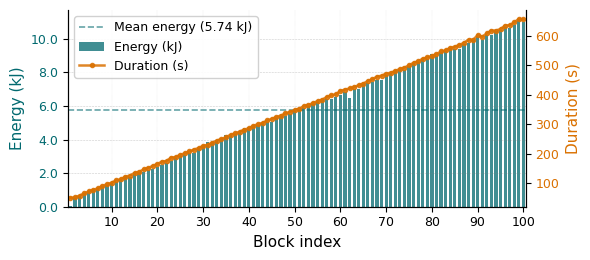

PDF : /home/paco/Proyectos/WAID/plots/energy_time_per_block.pdf
PNG : /home/paco/Proyectos/WAID/plots/energy_time_per_block.png
Run ID         : waidplus_11n4_L3
Bloques        : 100
Energía total  : 574.354 kJ  (0.1595 Wh)
Duración total : 35159.1 s  (585.99 min)
Energía media  : 5.744 kJ/bloque


In [26]:
#!/usr/bin/env python3
"""
Energía por bloque (barras) + Tiempo por bloque (línea) — eje Y dual
=====================================================================
Archivos de entrada:
    - logs/Jetson/history_ReTrain.csv
    - logs/Jetson/waidplus_blocks_times.csv

Salida:
    - plots/energy_time_per_block.pdf / .png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Rutas ──────────────────────────────────────────────────────────────────
DEVICE = "Jetson"

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

ROOT_DIR   = BASE_DIR.parent
DEVICE_DIR = ROOT_DIR / "logs" / DEVICE
PLOTS_DIR  = ROOT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

POWER_CSV  = DEVICE_DIR / "history_ReTrain.csv"
BLOCKS_CSV = DEVICE_DIR / "waidplus_blocks_times.csv"
OUTPUT_PDF = PLOTS_DIR  / "energy_time_per_block.pdf"
OUTPUT_PNG = PLOTS_DIR  / "energy_time_per_block.png"

# ── Configuración ──────────────────────────────────────────────────────────
BLOCKS_TZ  = "Europe/Madrid"
COLOR_ENERGY = "#01696f"
COLOR_TIME   = "#da7101"

# ── Carga de datos ─────────────────────────────────────────────────────────
df_power = pd.read_csv(POWER_CSV)
df_power["timestamp"] = pd.to_datetime(df_power["last_changed"], utc=True)
df_power["power_W"]   = pd.to_numeric(df_power["state"], errors="coerce")
df_power = (df_power
            .dropna(subset=["power_W"])
            .sort_values("timestamp")
            .reset_index(drop=True))

df_blocks = pd.read_csv(BLOCKS_CSV)
run_id = df_blocks.iloc[0]["RunId"]

# ── Parseo de bloques + cálculo de energía y duración ─────────────────────
records = []
n_blocks = (len(df_blocks.columns) - 1) // 2

for i in range(1, n_blocks + 1):
    ini_col, fin_col = f"B{i}_Ini", f"B{i}_Fin"
    if ini_col not in df_blocks.columns:
        break

    t_ini = (pd.to_datetime(df_blocks.iloc[0][ini_col])
               .tz_localize(BLOCKS_TZ).tz_convert("UTC"))
    t_fin = (pd.to_datetime(df_blocks.iloc[0][fin_col])
               .tz_localize(BLOCKS_TZ).tz_convert("UTC"))

    # Duración en segundos
    duration_s = (t_fin - t_ini).total_seconds()

    # Muestras de potencia dentro del bloque
    mask = (df_power["timestamp"] >= t_ini) & (df_power["timestamp"] <= t_fin)
    df_block = df_power.loc[mask].copy()

    if len(df_block) >= 2:
        t_s = (df_block["timestamp"] - t_ini).dt.total_seconds().values
        p_w = df_block["power_W"].values
        energy_j = np.trapezoid(p_w, t_s)          # Julios
        energy_kj = energy_j / 1000.0
    else:
        # Si no hay muestras suficientes, estimar con potencia media global
        energy_kj = df_power["power_W"].mean() * duration_s / 1000.0

    records.append({
        "block":      i,
        "duration_s": duration_s,
        "energy_kj":  energy_kj,
    })

df_res = pd.DataFrame(records)

# ── Figura con eje Y dual ──────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")
ax1.spines["top"].set_visible(False)

# --- Barras: energía (eje izquierdo) ---
ax1.bar(df_res["block"], df_res["energy_kj"],
        color=COLOR_ENERGY, alpha=0.75, width=0.7, label="Energy (kJ)")
ax1.set_xlabel("Block index", fontsize=11)
ax1.set_ylabel("Energy (kJ)", fontsize=11, color=COLOR_ENERGY)
ax1.tick_params(axis="y", labelcolor=COLOR_ENERGY, labelsize=9)
ax1.tick_params(axis="x", labelsize=9)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

# Línea de media energía
e_mean = df_res["energy_kj"].mean()
ax1.axhline(e_mean, color=COLOR_ENERGY, linewidth=1.2,
            linestyle="--", alpha=0.6, label=f"Mean energy ({e_mean:.2f} kJ)")

# --- Línea: tiempo (eje derecho) ---
ax2 = ax1.twinx()
ax2.plot(df_res["block"], df_res["duration_s"],
         color=COLOR_TIME, linewidth=1.8, marker="o",
         markersize=3, alpha=0.85, label="Duration (s)")
ax2.set_ylabel("Duration (s)", fontsize=11, color=COLOR_TIME)
ax2.tick_params(axis="y", labelcolor=COLOR_TIME, labelsize=9)
ax2.spines["top"].set_visible(False)

# Línea de media duración
#d_mean = df_res["duration_s"].mean()
#ax2.axhline(d_mean, color=COLOR_TIME, linewidth=1.2,linestyle="--", alpha=0.6, label=f"Mean duration ({d_mean:.1f} s)")

# ── Eje X: tick cada 10 bloques ────────────────────────────────────────────
ax1.set_xlim(left=0.5, right=len(df_res) + 0.5)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))


# ── Leyenda combinada ──────────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           fontsize=9, loc="upper left",ncol=1,
           #bbox_to_anchor=(0.5, -0.13), ncol=1,
           framealpha=0.9, edgecolor="#cccccc")

# ── Grid ───────────────────────────────────────────────────────────────────
ax1.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4, color="gray")
ax1.grid(axis="x", linestyle=":",  linewidth=0.3, alpha=0.3, color="gray")

# ── Stats al pie ───────────────────────────────────────────────────────────
total_e  = df_res["energy_kj"].sum()
total_t  = df_res["duration_s"].sum()
#stats_txt = (f"Total energy: {total_e:.2f} kJ ({total_e/3600:.3f} Wh)  | Total duration: {total_t:.0f} s ({total_t/60:.1f} min)  |  Blocks: {len(df_res)}")
#fig.text(0.5, 0.01, stats_txt, ha="center", fontsize=9, color="#555555", style="italic")

plt.tight_layout(rect=[0, 0.1, 1, 1])
fig.savefig(OUTPUT_PDF, bbox_inches="tight", facecolor="white")
#fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

print(f"PDF : {OUTPUT_PDF}")
print(f"PNG : {OUTPUT_PNG}")
print(f"Run ID         : {run_id}")
print(f"Bloques        : {len(df_res)}")
print(f"Energía total  : {total_e:.3f} kJ  ({total_e/3600:.4f} Wh)")
print(f"Duración total : {total_t:.1f} s  ({total_t/60:.2f} min)")
print(f"Energía media  : {e_mean:.3f} kJ/bloque")
#print(f"Duración media : {d_mean:.2f} s/bloque")